In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
data = pd.read_csv('AmericanHousingData.csv')
data

,Zip Code,Price,Beds,Baths,Living Space,Address,City,State,Zip Code Population,Zip Code Density,County,Median Household Income,Latitude,Longitude
0,10013,3999000.0,2,3,1967,74 GRAND ST APT 3,New York,New York,29563,20967.9,New York,370046.0,40.72001,-74.00472
1,10013,3999000.0,2,3,1967,74 GRAND ST APT 3,New York,New York,29563,20967.9,New York,370046.0,40.72001,-74.00472
2,10014,1650000.0,1,1,718,140 CHARLES ST APT 4D,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
3,10014,760000.0,3,2,1538,38 JONES ST,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
4,10014,1100000.0,1,1,600,81 BEDFORD ST APT 3F,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39976,98199,2495000.0,4,4,3380,2626 27TH AVE W,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39977,98199,2295000.0,4,4,2878,3215 32ND AVE W,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39978,98199,950000.0,3,2,1380,3257 22ND AVE W,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39979,98199,425000.0,2,1,856,3711 26TH PL W APT 102,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223


In [3]:
data.dtypes

Zip Code                     int64
Price                      float64
Beds                         int64
Baths                        int64
Living Space                 int64
Address                     object
City                        object
State                       object
Zip Code Population          int64
Zip Code Density           float64
County                      object
Median Household Income    float64
Latitude                   float64
Longitude                  float64
dtype: object

In [4]:
data.columns

Index(['Zip Code', 'Price', 'Beds', 'Baths', 'Living Space', 'Address', 'City',
       'State', 'Zip Code Population', 'Zip Code Density', 'County',
       'Median Household Income', 'Latitude', 'Longitude'],
      dtype='object')

In [5]:
data.drop('Address',axis=1,inplace=True)
data

,Zip Code,Price,Beds,Baths,Living Space,City,State,Zip Code Population,Zip Code Density,County,Median Household Income,Latitude,Longitude
0,10013,3999000.0,2,3,1967,New York,New York,29563,20967.9,New York,370046.0,40.72001,-74.00472
1,10013,3999000.0,2,3,1967,New York,New York,29563,20967.9,New York,370046.0,40.72001,-74.00472
2,10014,1650000.0,1,1,718,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
3,10014,760000.0,3,2,1538,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
4,10014,1100000.0,1,1,600,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39976,98199,2495000.0,4,4,3380,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39977,98199,2295000.0,4,4,2878,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39978,98199,950000.0,3,2,1380,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39979,98199,425000.0,2,1,856,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223


In [6]:
le_City = LabelEncoder()
data['City'] = le_City.fit_transform(data['City'])

le_State = LabelEncoder()
data['State'] = le_State.fit_transform(data['State'])

le_County = LabelEncoder()
data['County'] = le_County.fit_transform(data['County'])

data

,Zip Code,Price,Beds,Baths,Living Space,City,State,Zip Code Population,Zip Code Density,County,Median Household Income,Latitude,Longitude
0,10013,3999000.0,2,3,1967,150,18,29563,20967.9,57,370046.0,40.72001,-74.00472
1,10013,3999000.0,2,3,1967,150,18,29563,20967.9,57,370046.0,40.72001,-74.00472
2,10014,1650000.0,1,1,718,150,18,29815,23740.9,57,249880.0,40.73407,-74.00601
3,10014,760000.0,3,2,1538,150,18,29815,23740.9,57,249880.0,40.73407,-74.00601
4,10014,1100000.0,1,1,600,150,18,29815,23740.9,57,249880.0,40.73407,-74.00601
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39976,98199,2495000.0,4,4,3380,204,27,22890,2086.8,46,205611.0,47.65139,-122.40223
39977,98199,2295000.0,4,4,2878,204,27,22890,2086.8,46,205611.0,47.65139,-122.40223
39978,98199,950000.0,3,2,1380,204,27,22890,2086.8,46,205611.0,47.65139,-122.40223
39979,98199,425000.0,2,1,856,204,27,22890,2086.8,46,205611.0,47.65139,-122.40223


In [7]:
data.dtypes

Zip Code                     int64
Price                      float64
Beds                         int64
Baths                        int64
Living Space                 int64
City                         int64
State                        int64
Zip Code Population          int64
Zip Code Density           float64
County                       int64
Median Household Income    float64
Latitude                   float64
Longitude                  float64
dtype: object

In [8]:
data.isnull().sum()

Zip Code                   0
Price                      0
Beds                       0
Baths                      0
Living Space               0
City                       0
State                      0
Zip Code Population        0
Zip Code Density           0
County                     0
Median Household Income    2
Latitude                   0
Longitude                  0
dtype: int64

In [9]:
data = data.dropna()

In [10]:
data.isnull().sum()

Zip Code                   0
Price                      0
Beds                       0
Baths                      0
Living Space               0
City                       0
State                      0
Zip Code Population        0
Zip Code Density           0
County                     0
Median Household Income    0
Latitude                   0
Longitude                  0
dtype: int64

In [11]:
# df=df.drop_duplicates()

{'whiskers': [<matplotlib.lines.Line2D at 0x12a0a01af90>,
 'caps': [<matplotlib.lines.Line2D at 0x12a0a01b230>,
 'boxes': [<matplotlib.patches.PathPatch at 0x12a0a019a90>],
 'medians': [<matplotlib.lines.Line2D at 0x12a0a01b4d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x12a0a01b620>],
 'means': []}

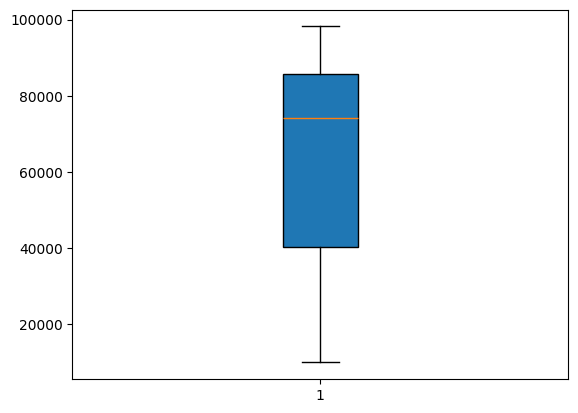

In [12]:
plt.boxplot(data['Zip Code'],patch_artist=True)

{'whiskers': [<matplotlib.lines.Line2D at 0x12a0a0727b0>,
 'caps': [<matplotlib.lines.Line2D at 0x12a0a072a50>,
 'boxes': [<matplotlib.patches.PathPatch at 0x12a0a086490>],
 'medians': [<matplotlib.lines.Line2D at 0x12a0a072cf0>],
 'fliers': [<matplotlib.lines.Line2D at 0x12a0a072e40>],
 'means': []}

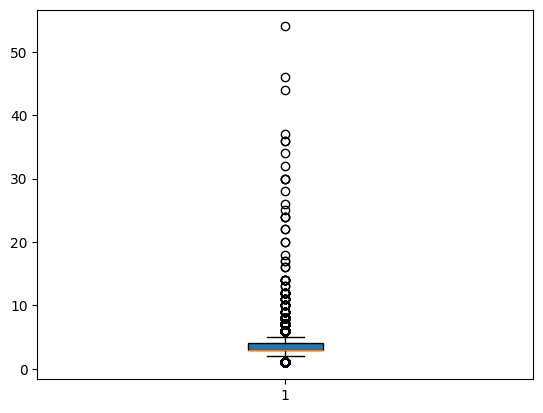

In [13]:
plt.boxplot(data['Beds'],patch_artist=True)

In [14]:
q1 = data.Beds.quantile(0.25)
q3 = data.Beds.quantile(0.75)
IQR = q3-q1

lower= q1 - 1.5 * IQR
upper= q3 + 1.5 * IQR

upper_index = np.where(data['Beds'] >= upper)[0]
lower_index = np.where(data['Beds'] <= lower)[0]

data.drop(index = upper_index, inplace = True)
data.drop(index = lower_index, inplace = True)

C:\Users\admin\AppData\Local\Temp\ipykernel_7976\1858553043.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(index = upper_index, inplace = True)
C:\Users\admin\AppData\Local\Temp\ipykernel_7976\1858553043.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(index = lower_index, inplace = True)


{'whiskers': [<matplotlib.lines.Line2D at 0x12a09e71be0>,
 'caps': [<matplotlib.lines.Line2D at 0x12a09e71e80>,
 'boxes': [<matplotlib.patches.PathPatch at 0x12a09e66e90>],
 'medians': [<matplotlib.lines.Line2D at 0x12a09e72120>],
 'fliers': [<matplotlib.lines.Line2D at 0x12a09e72270>],
 'means': []}

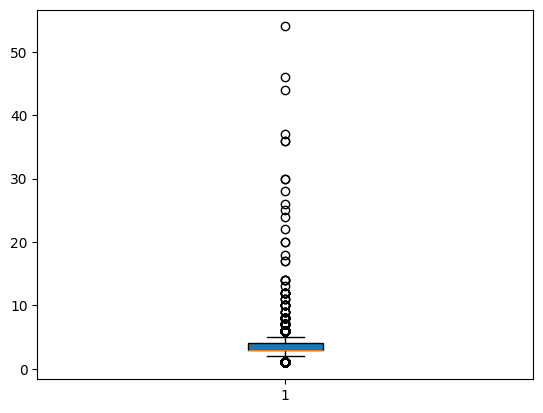

In [15]:
plt.boxplot(data['Beds'],patch_artist=True)

In [16]:
data.reset_index(inplace=True)
data.drop('index', axis=1, inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_7976\46725592.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop('index', axis=1, inplace=True)


In [17]:
q1 = data.Beds.quantile(0.25)
q3 = data.Beds.quantile(0.75)
IQR = q3-q1

lower= q1 - 1.5 * IQR
upper= q3 + 1.5 * IQR

upper_index = np.where(data['Beds'] >= upper)[0]
lower_index = np.where(data['Beds'] <= lower)[0]

data.drop(index = upper_index, inplace = True)
data.drop(index = lower_index, inplace = True)

C:\Users\admin\AppData\Local\Temp\ipykernel_7976\1858553043.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(index = upper_index, inplace = True)
C:\Users\admin\AppData\Local\Temp\ipykernel_7976\1858553043.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(index = lower_index, inplace = True)


{'whiskers': [<matplotlib.lines.Line2D at 0x12a09fc9010>,
 'caps': [<matplotlib.lines.Line2D at 0x12a09fc92b0>,
 'boxes': [<matplotlib.patches.PathPatch at 0x12a09e03110>],
 'medians': [<matplotlib.lines.Line2D at 0x12a09fc9550>],
 'fliers': [<matplotlib.lines.Line2D at 0x12a09fc96a0>],
 'means': []}

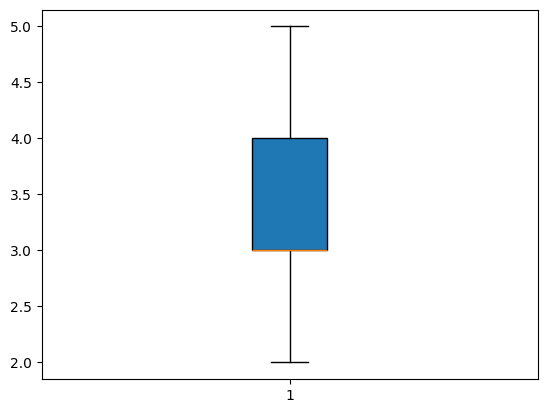

In [18]:
plt.boxplot(data['Beds'], patch_artist=True)

In [19]:
data.reset_index(inplace=True)
data.drop('index', axis=1, inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_7976\46725592.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop('index', axis=1, inplace=True)


{'whiskers': [<matplotlib.lines.Line2D at 0x12a09f48830>,
 'caps': [<matplotlib.lines.Line2D at 0x12a09f48ad0>,
 'boxes': [<matplotlib.patches.PathPatch at 0x12a09f87610>],
 'medians': [<matplotlib.lines.Line2D at 0x12a09f48d70>],
 'fliers': [<matplotlib.lines.Line2D at 0x12a09f48ec0>],
 'means': []}

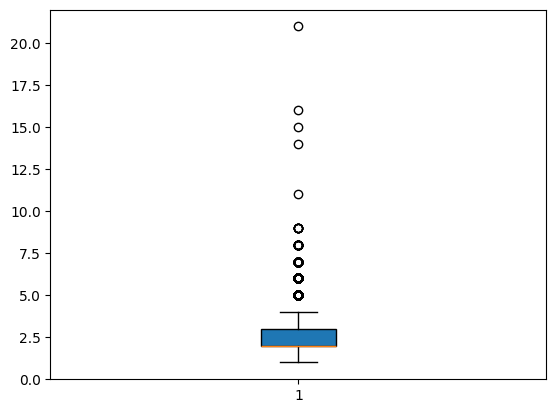

In [20]:
plt.boxplot(data['Baths'], patch_artist=True)

In [21]:
q1 = data.Baths.quantile(0.25)
q3 = data.Baths.quantile(0.75)
IQR = q3-q1

lower= q1 - 1.5 * IQR
upper= q3 + 1.5 * IQR

upper_index = np.where(data['Baths'] >= upper)[0]
lower_index = np.where(data['Baths'] <= lower)[0]

data.drop(index = upper_index, inplace = True)
data.drop(index = lower_index, inplace = True)

C:\Users\admin\AppData\Local\Temp\ipykernel_7976\2265130254.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(index = upper_index, inplace = True)
C:\Users\admin\AppData\Local\Temp\ipykernel_7976\2265130254.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(index = lower_index, inplace = True)


{'whiskers': [<matplotlib.lines.Line2D at 0x12a0a3c8440>,
 'caps': [<matplotlib.lines.Line2D at 0x12a0a3c86e0>,
 'boxes': [<matplotlib.patches.PathPatch at 0x12a09f1bc50>],
 'medians': [<matplotlib.lines.Line2D at 0x12a0a3c8980>],
 'fliers': [<matplotlib.lines.Line2D at 0x12a0a3c8ad0>],
 'means': []}

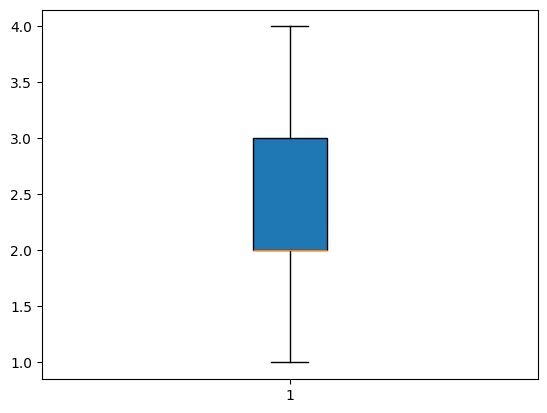

In [22]:
plt.boxplot(data['Baths'], patch_artist = True)

In [23]:
data.reset_index(inplace=True)
data.drop('index', axis=1, inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_7976\46725592.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop('index', axis=1, inplace=True)


{'whiskers': [<matplotlib.lines.Line2D at 0x12a0a3cbb60>,
 'caps': [<matplotlib.lines.Line2D at 0x12a0a3cbe00>,
 'boxes': [<matplotlib.patches.PathPatch at 0x12a0a440050>],
 'medians': [<matplotlib.lines.Line2D at 0x12a0a4481a0>],
 'fliers': [<matplotlib.lines.Line2D at 0x12a0a4482f0>],
 'means': []}

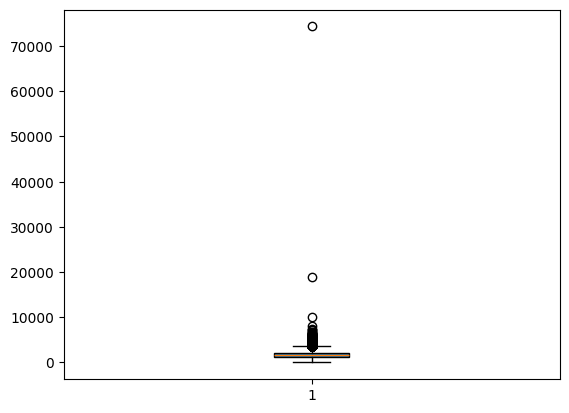

In [24]:
plt.boxplot(data['Living Space'], patch_artist=True)

In [25]:
q1 = data['Living Space'].quantile(0.25)
q3 = data['Living Space'].quantile(0.75)
IQR = q3-q1

lower= q1 - 1.5 * IQR
upper= q3 + 1.5 * IQR

upper_index = np.where(data['Living Space'] >= upper)[0]
lower_index = np.where(data['Living Space'] <= lower)[0]

data.drop(index = upper_index, inplace = True)
data.drop(index = lower_index, inplace = True)

C:\Users\admin\AppData\Local\Temp\ipykernel_7976\676568713.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(index = upper_index, inplace = True)
C:\Users\admin\AppData\Local\Temp\ipykernel_7976\676568713.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(index = lower_index, inplace = True)


{'whiskers': [<matplotlib.lines.Line2D at 0x12a0a44b770>,
 'caps': [<matplotlib.lines.Line2D at 0x12a0a44ba10>,
 'boxes': [<matplotlib.patches.PathPatch at 0x12a0a49c7d0>],
 'medians': [<matplotlib.lines.Line2D at 0x12a0a44bcb0>],
 'fliers': [<matplotlib.lines.Line2D at 0x12a0a44be00>],
 'means': []}

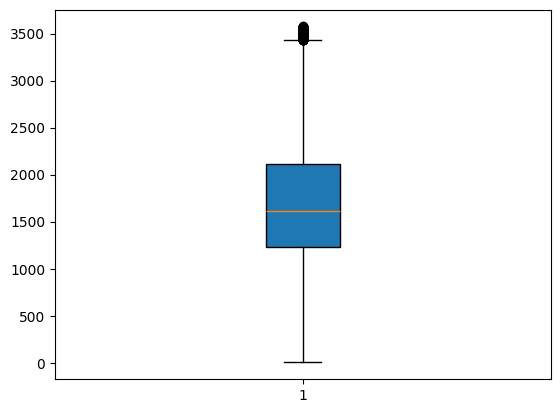

In [26]:
plt.boxplot(data['Living Space'], patch_artist=True)

In [27]:
data.reset_index(inplace=True)
data.drop('index', axis=1, inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_7976\46725592.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop('index', axis=1, inplace=True)


In [28]:
data.columns

Index(['Zip Code', 'Price', 'Beds', 'Baths', 'Living Space', 'City', 'State',
       'Zip Code Population', 'Zip Code Density', 'County',
       'Median Household Income', 'Latitude', 'Longitude'],
      dtype='object')

{'whiskers': [<matplotlib.lines.Line2D at 0x12a0a26b380>,
 'caps': [<matplotlib.lines.Line2D at 0x12a0a26b620>,
 'boxes': [<matplotlib.patches.PathPatch at 0x12a0a2a8f50>],
 'medians': [<matplotlib.lines.Line2D at 0x12a0a26b8c0>],
 'fliers': [<matplotlib.lines.Line2D at 0x12a0a26ba10>],
 'means': []}

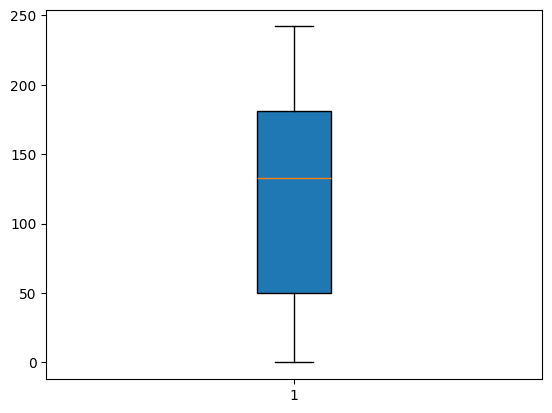

In [29]:
plt.boxplot(data['City'], patch_artist=True)

{'whiskers': [<matplotlib.lines.Line2D at 0x12a0a2de7b0>,
 'caps': [<matplotlib.lines.Line2D at 0x12a0a2dea50>,
 'boxes': [<matplotlib.patches.PathPatch at 0x12a0a314f50>],
 'medians': [<matplotlib.lines.Line2D at 0x12a0a2decf0>],
 'fliers': [<matplotlib.lines.Line2D at 0x12a0a2dee40>],
 'means': []}

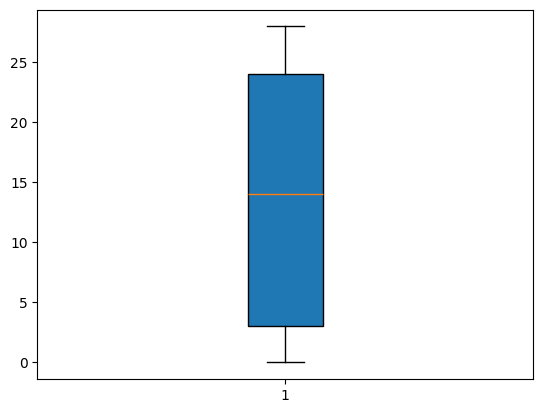

In [30]:
plt.boxplot(data['State'], patch_artist=True)

{'whiskers': [<matplotlib.lines.Line2D at 0x12a0a34dbe0>,
 'caps': [<matplotlib.lines.Line2D at 0x12a0a34de80>,
 'boxes': [<matplotlib.patches.PathPatch at 0x12a0aa2cf50>],
 'medians': [<matplotlib.lines.Line2D at 0x12a0a34e120>],
 'fliers': [<matplotlib.lines.Line2D at 0x12a0a34e270>],
 'means': []}

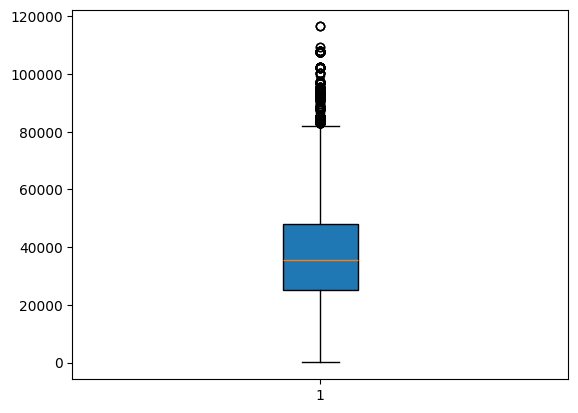

In [31]:
plt.boxplot(data['Zip Code Population'], patch_artist=True)

In [32]:
q1 = data['Zip Code Population'].quantile(0.25)
q3 = data['Zip Code Population'].quantile(0.75)
IQR = q3-q1

lower= q1 - 1.5 * IQR
upper= q3 + 1.5 * IQR

upper_index = np.where(data['Zip Code Population'] >= upper)[0]
lower_index = np.where(data['Zip Code Population'] <= lower)[0]

data.drop(index = upper_index, inplace = True)
data.drop(index = lower_index, inplace = True)

C:\Users\admin\AppData\Local\Temp\ipykernel_7976\1258654374.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(index = upper_index, inplace = True)
C:\Users\admin\AppData\Local\Temp\ipykernel_7976\1258654374.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(index = lower_index, inplace = True)


{'whiskers': [<matplotlib.lines.Line2D at 0x12a0aa79400>,
 'caps': [<matplotlib.lines.Line2D at 0x12a0aa796a0>,
 'boxes': [<matplotlib.patches.PathPatch at 0x12a0aaa16d0>],
 'medians': [<matplotlib.lines.Line2D at 0x12a0aa79940>],
 'fliers': [<matplotlib.lines.Line2D at 0x12a0aa79a90>],
 'means': []}

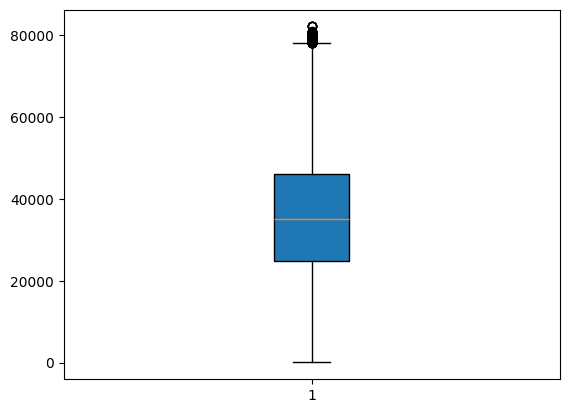

In [33]:
plt.boxplot(data['Zip Code Population'], patch_artist=True)

In [34]:
data.reset_index(inplace=True)
data.drop('index', axis=1, inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_7976\46725592.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop('index', axis=1, inplace=True)


{'whiskers': [<matplotlib.lines.Line2D at 0x12a0a8c4440>,
 'caps': [<matplotlib.lines.Line2D at 0x12a0a8c46e0>,
 'boxes': [<matplotlib.patches.PathPatch at 0x12a0aafd310>],
 'medians': [<matplotlib.lines.Line2D at 0x12a0a8c4980>],
 'fliers': [<matplotlib.lines.Line2D at 0x12a0a8c4ad0>],
 'means': []}

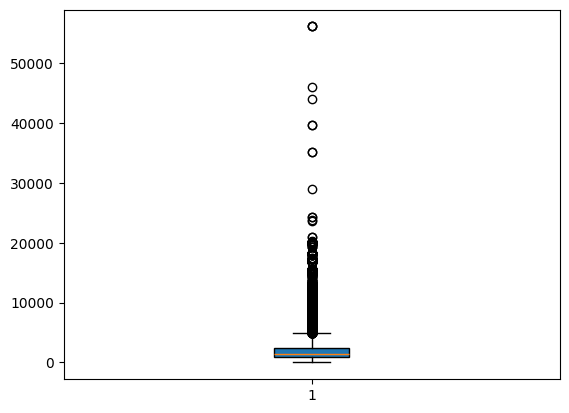

In [35]:
plt.boxplot(data['Zip Code Density'], patch_artist=True)

In [36]:
q1 = data['Zip Code Density'].quantile(0.25)
q3 = data['Zip Code Density'].quantile(0.75)
IQR = q3-q1

lower= q1 - 1.5 * IQR
upper= q3 + 1.5 * IQR

upper_index = np.where(data['Zip Code Density'] >= upper)[0]
lower_index = np.where(data['Zip Code Density'] <= lower)[0]

data.drop(index = upper_index, inplace = True)
data.drop(index = lower_index, inplace = True)

C:\Users\admin\AppData\Local\Temp\ipykernel_7976\4243138697.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(index = upper_index, inplace = True)
C:\Users\admin\AppData\Local\Temp\ipykernel_7976\4243138697.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(index = lower_index, inplace = True)


{'whiskers': [<matplotlib.lines.Line2D at 0x12a0a8c7770>,
 'caps': [<matplotlib.lines.Line2D at 0x12a0a8c7a10>,
 'boxes': [<matplotlib.patches.PathPatch at 0x12a0a91d310>],
 'medians': [<matplotlib.lines.Line2D at 0x12a0a8c7cb0>],
 'fliers': [<matplotlib.lines.Line2D at 0x12a0a8c7e00>],
 'means': []}

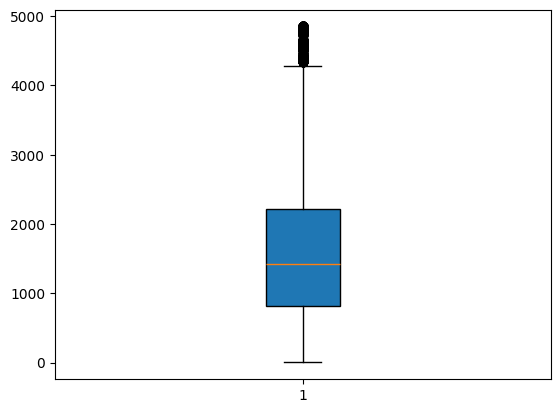

In [37]:
plt.boxplot(data['Zip Code Density'], patch_artist=True)

{'whiskers': [<matplotlib.lines.Line2D at 0x12a0a90eba0>,
 'caps': [<matplotlib.lines.Line2D at 0x12a0a90ee40>,
 'boxes': [<matplotlib.patches.PathPatch at 0x12a0a985310>],
 'medians': [<matplotlib.lines.Line2D at 0x12a0a90f0e0>],
 'fliers': [<matplotlib.lines.Line2D at 0x12a0a90f230>],
 'means': []}

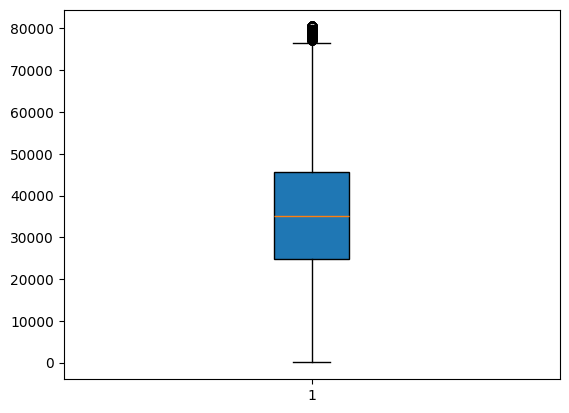

In [38]:
plt.boxplot(data['Zip Code Population'], patch_artist=True)


{'whiskers': [<matplotlib.lines.Line2D at 0x12a0a9beba0>,
 'caps': [<matplotlib.lines.Line2D at 0x12a0a9bee40>,
 'boxes': [<matplotlib.patches.PathPatch at 0x12a0ab41e50>],
 'medians': [<matplotlib.lines.Line2D at 0x12a0a9bf0e0>],
 'fliers': [<matplotlib.lines.Line2D at 0x12a0a9bf230>],
 'means': []}

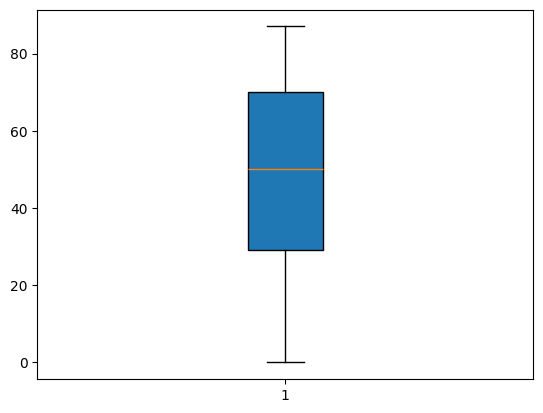

In [39]:
plt.boxplot(data['County'], patch_artist=True)

{'whiskers': [<matplotlib.lines.Line2D at 0x12a0ab85be0>,
 'caps': [<matplotlib.lines.Line2D at 0x12a0ab85e80>,
 'boxes': [<matplotlib.patches.PathPatch at 0x12a0aba5810>],
 'medians': [<matplotlib.lines.Line2D at 0x12a0ab86120>],
 'fliers': [<matplotlib.lines.Line2D at 0x12a0ab86270>],
 'means': []}

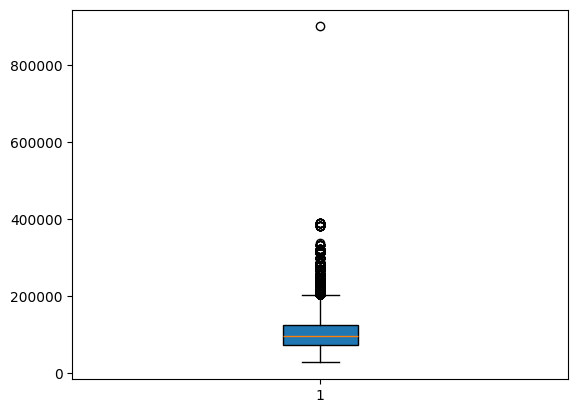

In [40]:
plt.boxplot(data['Median Household Income'], patch_artist=True)

In [41]:
data.reset_index(inplace=True)
data.drop('index', axis=1, inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_7976\46725592.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop('index', axis=1, inplace=True)


In [42]:
q1 = data['Median Household Income'].quantile(0.25)
q3 = data['Median Household Income'].quantile(0.75)
IQR = q3-q1

lower= q1 - 1.5 * IQR
upper= q3 + 1.5 * IQR

upper_index = np.where(data['Median Household Income'] >= upper)[0]
lower_index = np.where(data['Median Household Income'] <= lower)[0]

data.drop(index = upper_index, inplace = True)
data.drop(index = lower_index, inplace = True)

C:\Users\admin\AppData\Local\Temp\ipykernel_7976\3898211786.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(index = upper_index, inplace = True)
C:\Users\admin\AppData\Local\Temp\ipykernel_7976\3898211786.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(index = lower_index, inplace = True)


{'whiskers': [<matplotlib.lines.Line2D at 0x12a0a4ccc20>,
 'caps': [<matplotlib.lines.Line2D at 0x12a0a4ccec0>,
 'boxes': [<matplotlib.patches.PathPatch at 0x12a0ac09310>],
 'medians': [<matplotlib.lines.Line2D at 0x12a0a4cd160>],
 'fliers': [<matplotlib.lines.Line2D at 0x12a0a4cd2b0>],
 'means': []}

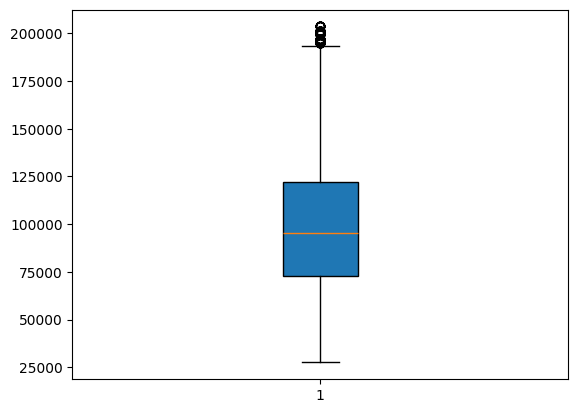

In [43]:
plt.boxplot(data['Median Household Income'], patch_artist=True)

In [44]:
data.reset_index(inplace=True)
data.drop('index', axis=1, inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_7976\46725592.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop('index', axis=1, inplace=True)


{'whiskers': [<matplotlib.lines.Line2D at 0x12a0a540830>,
 'caps': [<matplotlib.lines.Line2D at 0x12a0a540ad0>,
 'boxes': [<matplotlib.patches.PathPatch at 0x12a0a525a90>],
 'medians': [<matplotlib.lines.Line2D at 0x12a0a540d70>],
 'fliers': [<matplotlib.lines.Line2D at 0x12a0a540ec0>],
 'means': []}

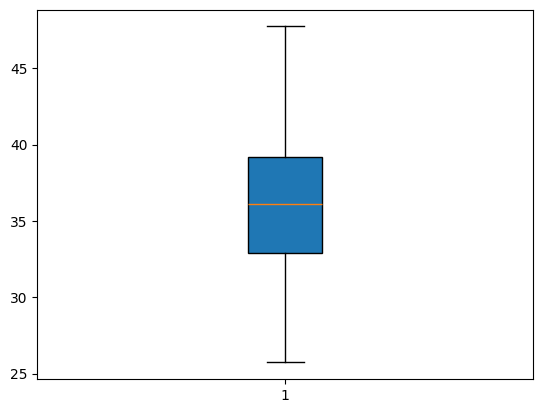

In [45]:
plt.boxplot(data['Latitude'], patch_artist=True)

{'whiskers': [<matplotlib.lines.Line2D at 0x12a0a543770>,
 'caps': [<matplotlib.lines.Line2D at 0x12a0a543a10>,
 'boxes': [<matplotlib.patches.PathPatch at 0x12a0a5996d0>],
 'medians': [<matplotlib.lines.Line2D at 0x12a0a543cb0>],
 'fliers': [<matplotlib.lines.Line2D at 0x12a0a543e00>],
 'means': []}

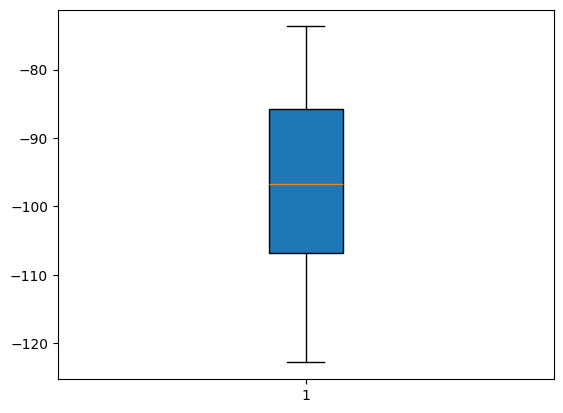

In [46]:
plt.boxplot(data['Longitude'], patch_artist=True)

{'whiskers': [<matplotlib.lines.Line2D at 0x12a0a5d27b0>,
 'caps': [<matplotlib.lines.Line2D at 0x12a0a5d2a50>,
 'boxes': [<matplotlib.patches.PathPatch at 0x12a0a5f5310>],
 'medians': [<matplotlib.lines.Line2D at 0x12a0a5d2cf0>],
 'fliers': [<matplotlib.lines.Line2D at 0x12a0a5d2e40>],
 'means': []}

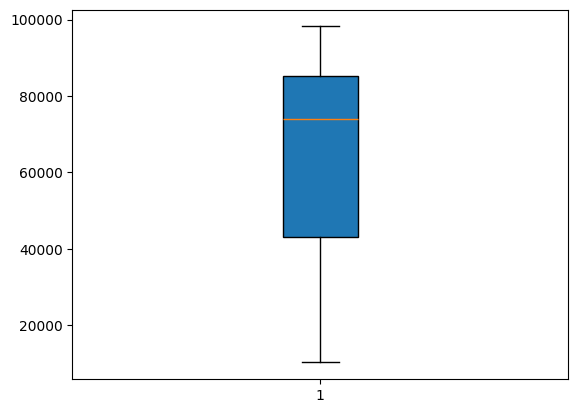

In [47]:
plt.boxplot(data['Zip Code'], patch_artist=True)

In [48]:
correlation = data.corr()
correlation

,Zip Code,Price,Beds,Baths,Living Space,City,State,Zip Code Population,Zip Code Density,County,Median Household Income,Latitude,Longitude
Zip Code,1.000000,0.209820,0.008705,-0.017887,0.042700,0.089928,-0.193085,-0.039483,0.059938,-0.070388,0.159754,-0.057707,-0.935443
Price,0.209820,1.000000,0.185014,0.379914,0.405616,0.117895,-0.195045,-0.004050,0.237476,0.014871,0.520516,-0.084566,-0.298316
Beds,0.008705,0.185014,1.000000,0.452910,0.617816,-0.015620,0.067391,0.078877,-0.137967,0.006676,0.049810,-0.043278,0.018104
Baths,-0.017887,0.379914,0.452910,1.000000,0.686776,-0.018199,0.055365,0.063842,-0.112010,-0.046370,0.293977,-0.124017,0.017631
Living Space,0.042700,0.405616,0.617816,0.686776,1.000000,-0.010626,0.068914,0.001976,-0.176110,-0.024321,0.285499,-0.080529,-0.013659
City,0.089928,0.117895,-0.015620,-0.018199,-0.010626,1.000000,-0.086521,-0.040357,0.038847,0.309544,0.104387,0.093009,-0.171297
State,-0.193085,-0.195045,0.067391,0.055365,0.068914,-0.086521,1.000000,0.078992,-0.135489,0.088170,-0.072370,0.022891,0.325374
Zip Code Population,-0.039483,-0.004050,0.078877,0.063842,0.001976,-0.040357,0.078992,1.000000,0.071873,-0.051409,-0.027933,-0.113662,-0.002877
Zip Code Density,0.059938,0.237476,-0.137967,-0.112010,-0.176110,0.038847,-0.135489,0.071873,1.000000,-0.043425,0.021964,0.233971,-0.108685
County,-0.070388,0.014871,0.006676,-0.046370,-0.024321,0.309544,0.088170,-0.051409,-0.043425,1.000000,0.018429,0.010245,0.080487


<Axes: >

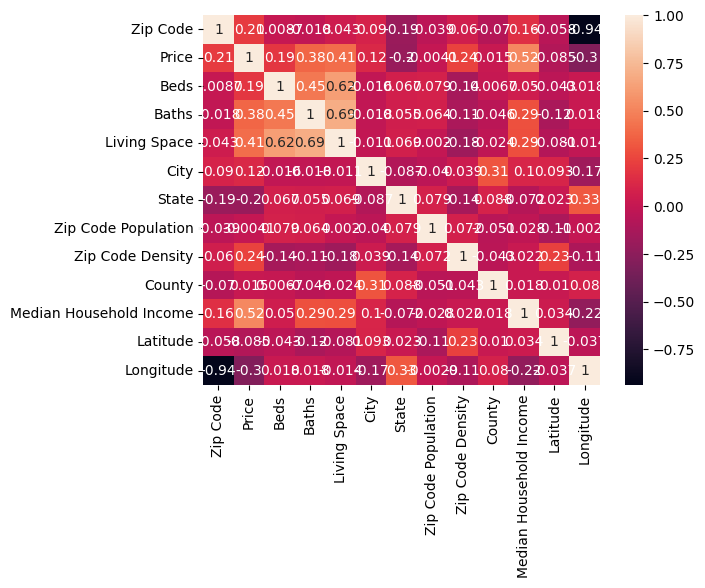

In [49]:
sns.heatmap(correlation, annot=True)

In [50]:
data.drop('Zip Code Population', axis=1, inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_7976\1127822671.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop('Zip Code Population', axis=1, inplace=True)


In [51]:
data.drop('County', axis=1, inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_7976\2766149167.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop('County', axis=1, inplace=True)


In [52]:
data.drop('Latitude', axis=1, inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_7976\348445166.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop('Latitude', axis=1, inplace=True)


In [53]:
data.drop('Zip Code', axis=1, inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_7976\2935761609.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop('Zip Code', axis=1, inplace=True)


In [54]:
correlation = data.corr()
correlation

,Price,Beds,Baths,Living Space,City,State,Zip Code Density,Median Household Income,Longitude
Price,1.000000,0.185014,0.379914,0.405616,0.117895,-0.195045,0.237476,0.520516,-0.298316
Beds,0.185014,1.000000,0.452910,0.617816,-0.015620,0.067391,-0.137967,0.049810,0.018104
Baths,0.379914,0.452910,1.000000,0.686776,-0.018199,0.055365,-0.112010,0.293977,0.017631
Living Space,0.405616,0.617816,0.686776,1.000000,-0.010626,0.068914,-0.176110,0.285499,-0.013659
City,0.117895,-0.015620,-0.018199,-0.010626,1.000000,-0.086521,0.038847,0.104387,-0.171297
State,-0.195045,0.067391,0.055365,0.068914,-0.086521,1.000000,-0.135489,-0.072370,0.325374
Zip Code Density,0.237476,-0.137967,-0.112010,-0.176110,0.038847,-0.135489,1.000000,0.021964,-0.108685
Median Household Income,0.520516,0.049810,0.293977,0.285499,0.104387,-0.072370,0.021964,1.000000,-0.224919
Longitude,-0.298316,0.018104,0.017631,-0.013659,-0.171297,0.325374,-0.108685,-0.224919,1.000000


<Axes: >

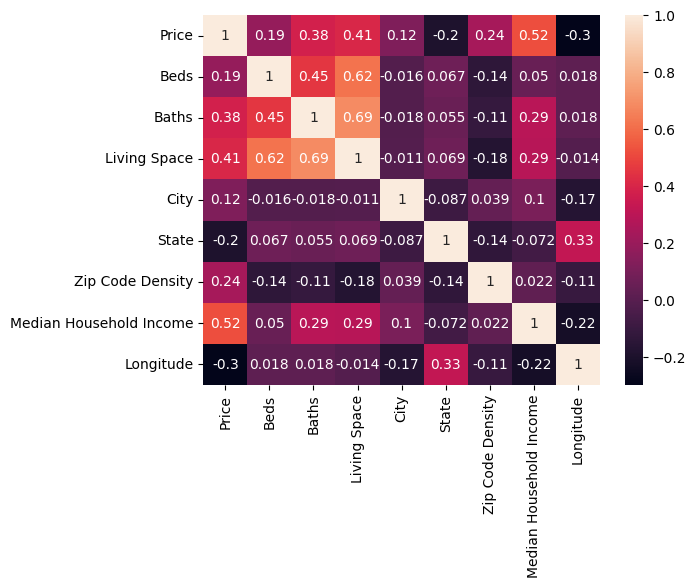

In [55]:
sns.heatmap(correlation, annot=True)

In [56]:
x = data.drop('Price', axis=1)
y = data['Price']

In [57]:
# x=df[['Beds','Baths','Living Space']]
# y=df['Price']

In [58]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=20)

In [59]:
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [60]:
model.score(x_test,y_test)

0.4562753841347116

In [61]:
model.score(x_train,y_train)

0.4787577178564896

In [62]:
y_pred=model.predict(x_test)

In [63]:
pd.DataFrame({'True values': y_test, 'Predicted values': y_pred})

,True values,Predicted values
7350,539900.0,431025.647230
28876,550000.0,284422.133293
23451,495000.0,695530.997240
28903,791000.0,861779.659778
15796,349950.0,384005.432518
...,...,...
12197,119900.0,118359.276066
11811,150000.0,62712.960776
19775,179950.0,289904.641500
25704,968800.0,662545.986839


In [64]:
mean_absolute_error(y_test,y_pred)

153327.85411612762

In [65]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE:",mse)
print("R2:",r2)

MSE: 72130236677.98265
R2: 0.4562753841347116


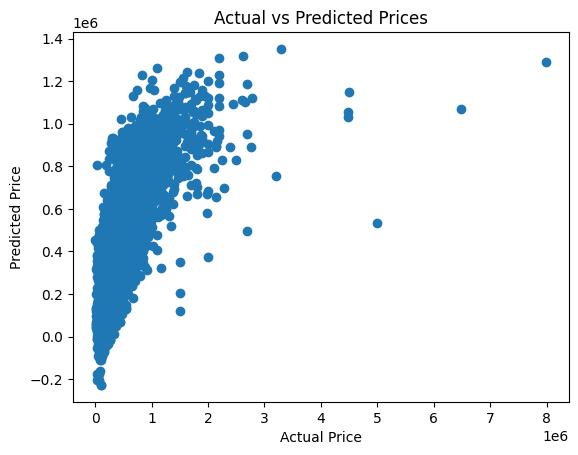

In [66]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

In [67]:
# import joblib

In [68]:
# joblib.dump(model, 'housing_model.pkl')

In [69]:
data.columns

Index(['Price', 'Beds', 'Baths', 'Living Space', 'City', 'State',
       'Zip Code Density', 'Median Household Income', 'Longitude'],
      dtype='object')

In [70]:
city_mapping = dict(zip(le_City.classes_, range(len(le_City.classes_))))
state_mapping = dict(zip(le_State.classes_, range(len(le_State.classes_))))

print("CITY MAP:")
print(city_mapping)

print("\nSTATE MAP:")
print(state_mapping)

print("\nSTATE-CITY:")
print(data[['State','City']].drop_duplicates().groupby('State')['City'].apply(list).to_dict())

CITY MAP:
{'Albuquerque': 0, 'Aledo': 1, 'Apache Junction': 2, 'Arlington': 3, 'Arverne': 4, 'Astoria': 5, 'Atascosa': 6, 'Atlanta': 7, 'Atlantic Beach': 8, 'Austin': 9, 'Baltimore': 10, 'Bayside': 11, 'Bellerose': 12, 'Bellevue': 13, 'Bennington': 14, 'Berkeley': 15, 'Beverly Hills': 16, 'Blacklick': 17, 'Boerne': 18, 'Broken Arrow': 19, 'Bronx': 20, 'Brooklyn': 21, 'Brownsburg': 22, 'Burbank': 23, 'Burleson': 24, 'Calhan': 25, 'Cambria Heights': 26, 'Campbell': 27, 'Canal Winchester': 28, 'Canoga Park': 29, 'Catonsville': 30, 'Cave Creek': 31, 'Charlotte': 32, 'Chatsworth': 33, 'Chesapeake': 34, 'Chicago': 35, 'Choctaw': 36, 'Clint': 37, 'College Point': 38, 'Colorado Springs': 39, 'Columbus': 40, 'Converse': 41, 'Cordova': 42, 'Corona': 43, 'Crowley': 44, 'Culver City': 45, 'Curtis Bay': 46, 'Dallas': 47, 'Del Mar': 48, 'Denver': 49, 'Detroit': 50, 'Dublin': 51, 'Dundalk': 52, 'Durham': 53, 'East Elmhurst': 54, 'Edmond': 55, 'El Paso': 56, 'Elkhorn': 57, 'Elmhurst': 58, 'Elmwood Par

In [71]:
city_mapping = dict(zip(le_City.classes_, range(len(le_City.classes_))))
state_mapping = dict(zip(le_State.classes_, range(len(le_State.classes_))))
state_city_mapping = (
    data[['State', 'City']]
    .drop_duplicates()
    .groupby('State')['City']
    .apply(list)
    .to_dict()
)

with open("mappings.py", "w", encoding="utf-8") as f:
    f.write("city_map = ")
    f.write(repr(city_mapping))
    f.write("\n\n")

    f.write("state_map = ")
    f.write(repr(state_mapping))
    f.write("\n\n")

    f.write("state_city_map = ")
    f.write(repr(state_city_mapping))